In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
file_path = "/workspaces/-/data/20804data.csv"
df = pd.read_csv(file_path, encoding="cp949")

In [5]:
rename_dict = {
    "구분": "Year",
    "기관사칭형_발생건수": "Gov_Impersonation_Cases",
    "기관사칭형_피해액_억원": "Gov_Impersonation_Loss_100M_KRW",
    "기관사칭형_검거인원": "Gov_Impersonation_Arrests",
    "대출사기형_발생건수": "Loan_Fraud_Cases",
    "대출사기형_피해액_억원": "Loan_Fraud_Loss_100M_KRW",
    "대출사기형_검거인원": "Loan_Fraud_Arrests",
}
df = df.rename(columns=rename_dict)

In [6]:
print("--- Preprocessed Data Preview ---")
print(df.head())
print("\n--- Data Information ---")
print(df.info())

--- Preprocessed Data Preview ---
   Year  Gov_Impersonation_Cases  Gov_Impersonation_Loss_100M_KRW  \
0  2016                     3384                              541   
1  2017                     5685                              967   
2  2018                     6221                             1430   
3  2019                     7219                             2506   
4  2020                     7844                             2144   

   Gov_Impersonation_Arrests  Loan_Fraud_Cases  Loan_Fraud_Loss_100M_KRW  \
0                       5682             13656                       927   
1                       4925             18574                      1503   
2                       5491             27911                      2610   
3                       6045             30448                      3892   
4                       4797             23837                      4856   

   Loan_Fraud_Arrests  
0                9884  
1               20548  
2               32133 

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

<Figure size 2000x600 with 0 Axes>

<Figure size 2000x600 with 0 Axes>

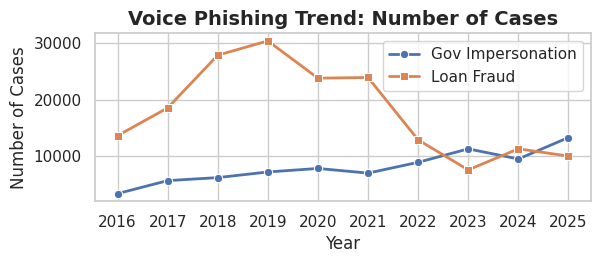

In [8]:
plt.subplot(2, 1, 2)
sns.lineplot(
    data=df,
    x="Year",
    y="Gov_Impersonation_Cases",
    marker="o",
    label="Gov Impersonation",
    linewidth=2,
)
sns.lineplot(
    data=df,
    x="Year",
    y="Loan_Fraud_Cases",
    marker="s",
    label="Loan Fraud",
    linewidth=2,
)
plt.title("Voice Phishing Trend: Number of Cases", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.xticks(df["Year"])
plt.legend()

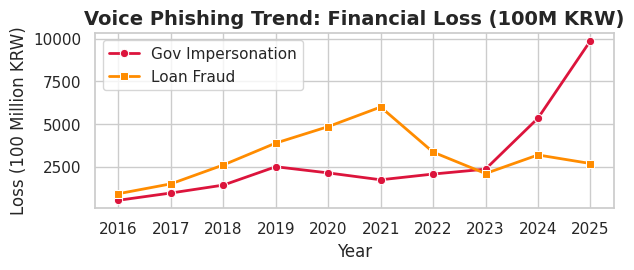

In [9]:
plt.subplot(2, 1, 2)
sns.lineplot(
    data=df,
    x="Year",
    y="Gov_Impersonation_Loss_100M_KRW",
    marker="o",
    label="Gov Impersonation",
    linewidth=2,
    color="crimson",
)
sns.lineplot(
    data=df,
    x="Year",
    y="Loan_Fraud_Loss_100M_KRW",
    marker="s",
    label="Loan Fraud",
    linewidth=2,
    color="darkorange",
)
plt.title(
    "Voice Phishing Trend: Financial Loss (100M KRW)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Year")
plt.ylabel("Loss (100 Million KRW)")
plt.xticks(df["Year"])
plt.legend()

plt.tight_layout()
plt.show()

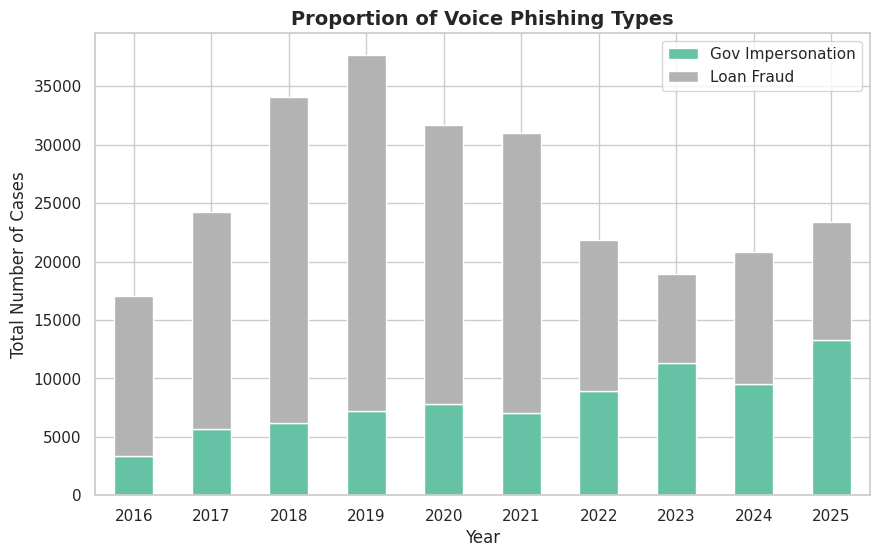

In [10]:
df_bar = df.set_index("Year")[["Gov_Impersonation_Cases", "Loan_Fraud_Cases"]]
df_bar.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")

plt.title("Proportion of Voice Phishing Types", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Number of Cases")
plt.xticks(rotation=0)
plt.legend(["Gov Impersonation", "Loan Fraud"])
plt.show()

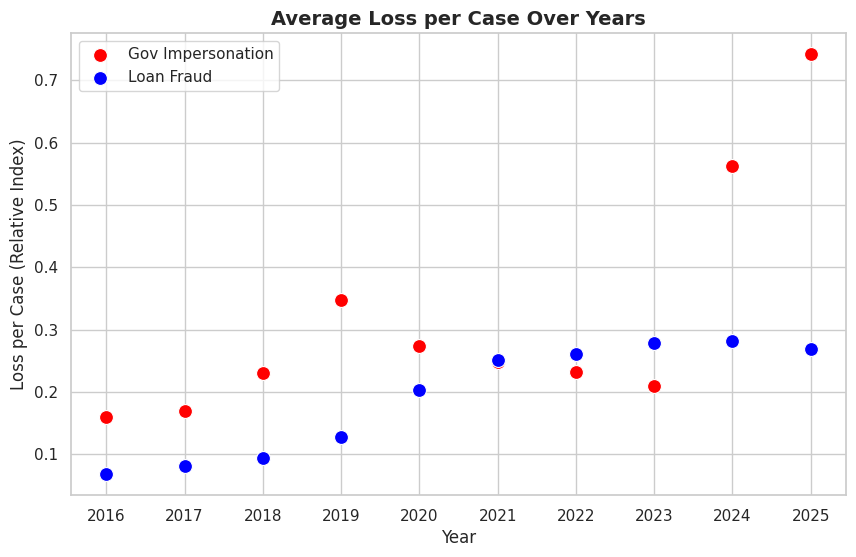

In [11]:
df["Gov_Loss_per_Case"] = df["Gov_Impersonation_Loss_100M_KRW"] / df["Gov_Impersonation_Cases"]
df["Loan_Loss_per_Case"] = df["Loan_Fraud_Loss_100M_KRW"] / df["Loan_Fraud_Cases"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Year", y="Gov_Loss_per_Case", s=100, label="Gov Impersonation", color="red")
sns.scatterplot(data=df, x="Year", y="Loan_Loss_per_Case", s=100, label="Loan Fraud", color="blue")

plt.title("Average Loss per Case Over Years", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Loss per Case (Relative Index)")
plt.xticks(df["Year"])
plt.legend()
plt.show()

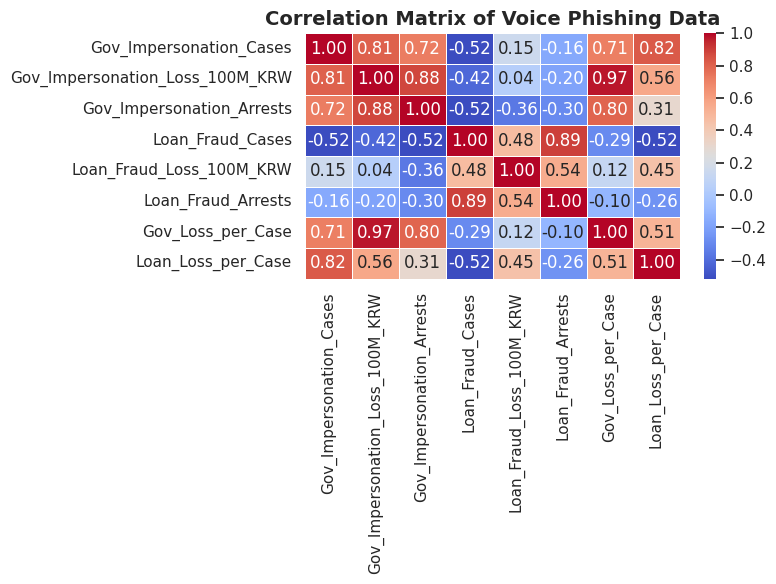

In [12]:
plt.figure(figsize=(8, 6))

corr_matrix = df.drop(columns=["Year"]).corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Voice Phishing Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()